# Kaggriculture: Findings from Zero to Top Meta

A field guide for the [Kaggriculture](https://www.kaggle.com/competitions/kaggriculture) simulation competition: what the public meta actually does, which engine details matter, and which strategies survive head-to-head.

**Competition type:** two-player farming simulation (720 turns). Ranking is a **skill rating** (win / loss / tie only — coin margin does not move Elo).

This notebook is an engineering diary and public-meta synthesis. Local bank totals are **not** the same as ladder score.

---

### What you will get

1. **Engine facts** that decide strategy (hire curve, melon yield window, shed vs inventory, fertilizer sells)
2. **Strategy clusters** from public notebooks and top-leader replays
3. **Reproducible local experiments** (price curves, hire costs, mini simulations)
4. **A progression of ideas** from pure cow ranch to staged herds to adaptive / tape policies
5. **A practical checklist** for your next submission
6. **A scorable competition artifact** — our best agent packaged as `submission.tar.gz` (and `main.py`)

### Credits (public work this draws on)

| Author / notebook | Idea |
| --- | --- |
| [Bovard — Getting Started](https://www.kaggle.com/code/bovard/kaggriculture-getting-started) | Official agent contract |
| [Georgy Mamarin — Visualized](https://www.kaggle.com/code/georgymamarin/kaggriculture-visualized-what-every-crop-pays) | Mechanics and market charts |
| [Roman Rozen — Barnyard Economist](https://www.kaggle.com/code/romanrozen/strong-statr-baseline-agent-lb-950) | Melon ripe timing, job-value framing |
| [Roman Tamrazov — Hamburger / Frontier](https://www.kaggle.com/code/romantamrazov/kaggriculture-hamburger) | Staged mixed-herd public baselines |
| [Pilkwang Kim — Scenario-Aware](https://www.kaggle.com/code/pilkwang/kaggriculture-scenario-aware-economic-policy) | Economic scheduler lineage |
| [Kun Zhang — C03 / C04 / C05](https://www.kaggle.com/code/beicicc/kaggriculture-c05-mid-herd-10) | Target herd 14 to 15, mid-herd 10 |
| [prvsiyan — Frontier Lab](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-lab-high-score-visuals) | Cross-play gates, C03 promotion |
| [prvsiyan — 720-Turn Farm Tape](https://www.kaggle.com/code/prvsiyan/kaggle-frontier-lab-strategy-improvement) | Public-tape routing ideas |
| Public leader replays (especially senkin13, plus dpquoc, syouya tobita, Kaito Fukami, and radiant-allomancer) | Stable efficiency schedules and adaptive herd fingerprints |

If this notebook helps you, **upvote and cite the original authors above** — this is synthesis and experiments on top of their work.


## 0. Setup

Uses the competition environment from `kaggle-environments` (see the competition data kit `AGENTS.md` / `README.md`).


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    installed_ke = version("kaggle-environments")
except PackageNotFoundError:
    installed_ke = "0"

# Kaggle's base notebook image may lag the competition runner. The replay-tape
# policies in this notebook require the current Kaggriculture mechanics.
# 1.32.4 is load-bearing, not just "recent": it made BUY_PRODUCT/BUY_SEED fail when
# the shed is at capacity, so a full shed can now silently block feed and starve
# animals. An agent tuned on 1.32.3 can desynchronise on the real runner.
if tuple(map(int, installed_ke.split(".")[:3])) < (1, 32, 4):
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-U", "kaggle-environments>=1.32.4"
    ])

import kaggle_environments
print("kaggle-environments", kaggle_environments.__version__)

from kaggle_environments import make

BOARD, DAYS, TURNS_PER_DAY = 10, 30, 24
EPISODE_STEPS = DAYS * TURNS_PER_DAY  # 720
STARTING_MONEY = 3000


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 744.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 43.1 MB/s eta 0:00:00
kaggle-environments 1.32.4


## 1. The game in one screen

| Knob | Default | Why it matters |
| --- | ---: | --- |
| Turns | 720 (30 x 24) | Long-horizon capital plan |
| Start cash | $3000 | Opening buys compete with each other |
| Land | NE $1k, SW $2k, SE $4k | Top public leaders almost always take **NE+SW**, rarely SE |
| Hire cost | fib(n) per extra hand **today** | First ~10 hands are cheap; 12+ gets expensive fast |
| Shed | 100 non-seed items | Overflow is destroyed — you must sell / liquidate |
| Win | Most **bank** coins | Unsold inventory does **not** count |
| Ladder | Skill rating | **Only** W/L/T; coin margin is irrelevant for Elo |

### Action economy beats the crop table

Each unit (farmer + hired hands) gets **one field op per turn**.  
A high-margin crop that costs two extra walks often loses to a weaker crop next to the shed.

**Rule of thumb:** hiring about 10 hands costs roughly **$143 for a full day** of parallelism. Under-hiring early is usually more expensive than over-hiring inside the cheap Fibonacci region.


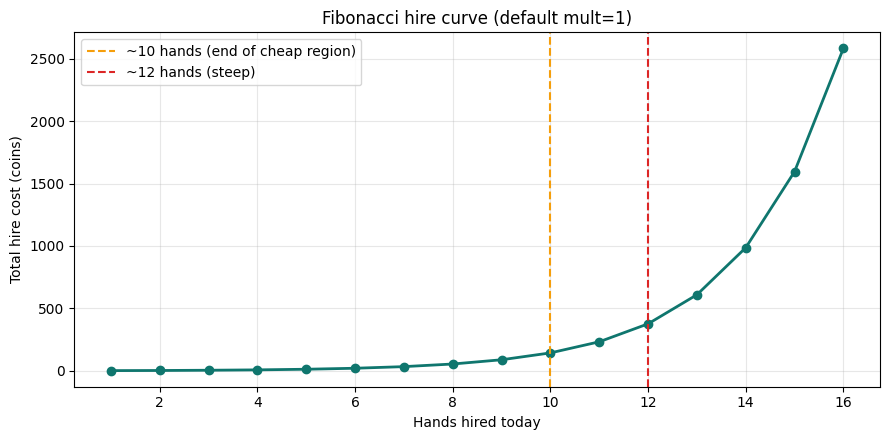

,hands,day_cost
5,6,20
7,8,54
9,10,143
10,11,232
11,12,376
13,14,986


In [2]:
def fib(n):
    a, b = 1, 1
    for _ in range(n):
        a, b = b, a + b
    return a


def hire_day_cost(n_hands):
    # total cost to hire n hands starting from 0 hires today (mult = 1)
    return sum(fib(i) for i in range(n_hands))


ns = np.arange(1, 17)
costs = [hire_day_cost(int(n)) for n in ns]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ns, costs, "o-", lw=2, color="#0f766e")
ax.axvline(10, color="#f59e0b", ls="--", label="~10 hands (end of cheap region)")
ax.axvline(12, color="#dc2626", ls="--", label="~12 hands (steep)")
ax.set(
    xlabel="Hands hired today",
    ylabel="Total hire cost (coins)",
    title="Fibonacci hire curve (default mult=1)",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame({"hands": ns, "day_cost": costs}).query("hands in [6, 8, 10, 11, 12, 14]")


## 2. Engine details that separate weak agents from strong ones

### 2.1 Melon yield window (trust the engine, not only the overview table)

For one-time crops, watering during a bonus window adds yield immediately:

- Melon `max_yield_day = 12` implies window start `ceil(12/2) = 6` → ages **6..12**
- A melon starts at `yield_units = 1`
- Each watered day in-window: **+1** (or **+2** if fertilized)
- Cap is **6**, so full water reaches max around **age 10**, not 12

**16 tiles x 6 = 96 melons** when execution is perfect.  
Missing water on days 6-10 is a common silent leak (for example ~70 units instead of ~96).

### 2.2 `SELL` only sees the shed

- `HARVEST` puts items into the **unit inventory**
- `SELL` spends items from the **shed**

If you harvest 90 melons and never `DROP` while shed-adjacent, the market may not see them until end-of-day auto-drop — often **too late** to fund same-turn land / animal buys.

### 2.3 Fertilizer can be sold

Competition text emphasizes buying fertilizer; the engine's generic `SELL` path still accepts it.  
Each animal generates fertilizer daily → a real sidecar income stream until the market is flooded.

### 2.4 Ladder scoring

Rating updates from **win / loss / tie only**.  
A 140k bank that loses still loses rating. Local mean bank vs `starter` is a useful filter, not the objective.


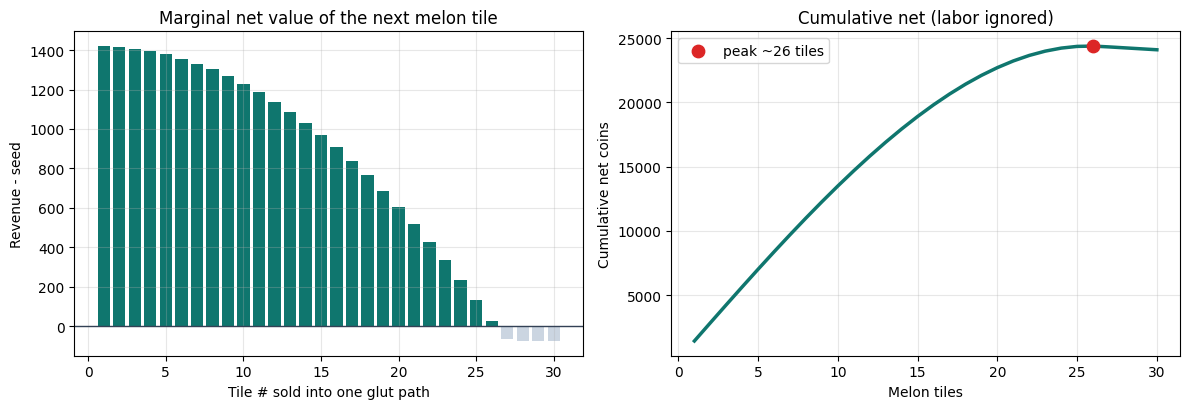

{'illustrative_peak_tiles': 26, 'note': 'Labor and rival sales move the real optimum; public leaders often use ~6-16 melons, not a full 25-tile dump.'}


In [3]:
# Illustrative melon glut curve (public MARKET_PARAMS style, glut side only)
I0, BASE, T = 10000, 250, 300
above_target = 3.6  # melon above_target


def melon_price(inv):
    x = max(0.0, inv - I0)
    amp = above_target * BASE / (T ** 2)
    return max(1, int(round(BASE - amp * x * x)))


units_per_tile = 6
tiles = np.arange(1, 31)
marginal = []
inv = I0
for t in tiles:
    rev = 0
    for _ in range(units_per_tile):
        p = melon_price(inv)
        rev += p
        if p > 1:
            inv += 1
    marginal.append(rev - 80)  # minus seed cost

cum = np.cumsum(marginal)
best = int(tiles[np.argmax(cum)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(tiles, marginal, color=["#0f766e" if v > 0 else "#cbd5e1" for v in marginal])
axes[0].axhline(0, color="#334155", lw=1)
axes[0].set(
    title="Marginal net value of the next melon tile",
    xlabel="Tile # sold into one glut path",
    ylabel="Revenue - seed",
)
axes[1].plot(tiles, cum, lw=2.5, color="#0f766e")
axes[1].scatter([best], [cum[best - 1]], s=80, color="#dc2626", zorder=3, label=f"peak ~{best} tiles")
axes[1].set(title="Cumulative net (labor ignored)", xlabel="Melon tiles", ylabel="Cumulative net coins")
axes[1].legend()
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print({
    "illustrative_peak_tiles": best,
    "note": "Labor and rival sales move the real optimum; public leaders often use ~6-16 melons, not a full 25-tile dump.",
})


## 3. Strategy clusters in the public meta

| Cluster | Opening | Peak farm | Strengths | Failure mode |
| --- | --- | --- | --- | --- |
| **A. Pure cow ranch** | 3-10 cows, little crop | ~10 cows, often NE only | Punishes soft / crop-only bots | Milk wars collapse banks; coin-flip H2H |
| **B. Melon IPO** | 16 melons + 2 cows | Day-10 dump to 12c+8s and 3 quads | Huge capital spike when uncontested | Second melon dumper hits the $1 floor |
| **C. Staged economic herd (C0x)** | **3 cows + 1 sheep** floor | Stages **4 to 8/10 to 14/15** | Strongest *public code* family | Everyone forks it → correlated losses |
| **D. Adaptive leader style** | 3c+1s, ~6 melons | Dynamic cow/sheep/goose mix | Rebalances when milk is contested | Harder to clone cleanly |
| **E. Stable efficiency tape** | Repeated elite trajectory | Tight 8c/6s production and labor schedule | Reproducible across opponents; current best live result | Can become correlated if widely copied |

### Approximate local strength ordering (sandbox H2H)

```text
starter << pure cow << melon IPO << C03 << C05 << Radiant routers << c11/c12/c13 << c14
```

**Caveat:** a bot that prints 100k-170k vs `starter` can still sit mid-ladder, because ladder opponents are other strong farms.


## 4. Top-leader replay fingerprints

The refreshed corpus contained five recent replays for each of the top five teams and 18 unique games after deduplicating shared episodes. Both players were treated as useful demonstrations.

### The strongest signal was schedule stability

The new senkin13 policy returned the **same complete 720-turn field and market schedule in five games against different opponents**. That made it a safer base than selecting one lucky winner trajectory.

Its mature portfolio is approximately:

- **8 cows + 6 sheep**
- about **7 strawberry plots**
- two land unlocks
- heavy use of cheap daily labor
- feed purchases coupled tightly to animal service

### What changed from the previous best schedule

| Metric | Previous c12 | New c14 source |
| --- | ---: | ---: |
| Hires issued | 292 | **304** |
| Cows / sheep bought | 8 / 7 | **8 / 6** |
| Wheat bought as product | 1,181 | **1,055** |
| Water actions | 672 | **791** |
| Harvest actions | 270 | **302** |
| Plant actions | 69 | **99** |
| Fertilize actions | 75 | **90** |

This is not merely a more aggressive seller: 668/720 field turns and 584/720 market turns changed. The new policy sells fewer total product units while finishing with more cash, indicating better labor utilization and a tighter inventory cycle.

### Isolation results

| Opponent | Paired-seat result |
| --- | ---: |
| c11 | **27-3** |
| c12 | **27-3** |
| c13 | **27-3** |
| c5 through c10 | **60-0 combined** |
| New dpquoc replay policy | **9-1** |
| New syouya replay policy | **9-1** |
| New Kaito replay policy | **8-2** |
| Sampled Radiant 6c/5s/3g policy | **10-0** |

The resulting c14 submission reached a public skill rating of **2192.9**. Ratings continue to move as games accumulate, so this is a dated observation rather than a final score.

**Takeaway:** first establish that a replay policy is stable across opponents, then isolate its field and market schedules in paired-seat tests. A replay winner is not automatically a good standalone agent.


In [4]:
openings = pd.DataFrame([
    {"name": "Pure cow open", "melon_seeds": 0, "cows": 3, "sheep": 0, "notes": "expand cows later"},
    {"name": "Melon IPO open", "melon_seeds": 16, "cows": 2, "sheep": 0, "notes": "dump around day 10"},
    {"name": "C0x / radiant open", "melon_seeds": 6, "cows": 3, "sheep": 1, "notes": "mixed option value"},
    {"name": "Nishchal-like open", "melon_seeds": 9, "cows": 4, "sheep": 0, "notes": "early dairy density"},
])
openings["seed_cost"] = openings.melon_seeds * 80
openings["animal_cost"] = openings.cows * 400 + openings.sheep * 500
openings["rough_spend"] = openings.seed_cost + openings.animal_cost
openings["cash_left_from_3000"] = STARTING_MONEY - openings.rough_spend
openings


,name,melon_seeds,cows,sheep,notes,seed_cost,animal_cost,rough_spend,cash_left_from_3000
0,Pure cow open,0,3,0,expand cows later,0,1200,1200,1800
1,Melon IPO open,16,2,0,dump around day 10,1280,800,2080,920
2,C0x / radiant open,6,3,1,mixed option value,480,1700,2180,820
3,Nishchal-like open,9,4,0,early dairy density,720,1600,2320,680


## 5. Live mini-simulations

### 5.1 Environment smoke test


In [5]:
def run_pair(a="starter", b="starter", seed=0, steps=720):
    env = make("kaggriculture", configuration={"episodeSteps": steps, "seed": seed}, debug=False)
    env.run([a, b])
    final = env.steps[-1]
    return {
        "seed": seed,
        "r0": final[0].reward,
        "r1": final[1].reward,
        "s0": str(final[0].status),
        "s1": str(final[1].status),
    }

pd.DataFrame([run_pair("starter", "random", seed=s) for s in range(3)])


,seed,r0,r1,s0,s1
0,0,3485.0,0.0,DONE,DONE
1,1,3487.0,0.0,DONE,DONE
2,2,3507.0,0.0,DONE,DONE


### 5.2 Built-in baseline matrix

Expect `starter` to beat `random` and `pass` on average. Your bot should crush `starter` locally before you overfit the public leaderboard number.


In [6]:
rows = []
for a, b in [("starter", "random"), ("starter", "pass"), ("random", "pass")]:
    for seed in range(2):
        rows.append({"a": a, "b": b, **run_pair(a, b, seed=seed)})
pd.DataFrame(rows)


,a,b,seed,r0,r1,s0,s1
0,starter,random,0,3487.0,0.0,DONE,DONE
1,starter,random,1,3499.0,0.0,DONE,DONE
2,starter,pass,0,3509.0,3000.0,DONE,DONE
3,starter,pass,1,3491.0,3000.0,DONE,DONE
4,random,pass,0,0.0,3000.0,DONE,DONE
5,random,pass,1,0.0,3000.0,DONE,DONE


## 6. A practical build ladder

### Stage 0 — Contract
- Implement `agent(obs)` returning `farmer` / `hands` / `market`
- Wrap in try/except so validation self-play cannot `ERROR`

### Stage 1 — Do not die
- Prioritize water/feed when `consecutive_un*` is already 1
- Hire into the cheap Fibonacci region (about 6-10 hands)
- Sell produce (and remember **DROP to shed**)

### Stage 2 — Pure cow (learning bot)
- 3-10 cows, NE land, fertilizer sell probe
- Great for learning operations; weak as a final once milk clones appear

### Stage 3 — Melon capital event
- Melon sleeve with full water on ages 6-12
- Optional day-10 IPO: sell melons -> land x2 -> herd
- Must DROP before SELL

### Stage 4 — Staged mixed herd (C0x family)
- Core **3 cows + 1 sheep**
- Expand capacity **4 -> 8/10 -> 14/15**
- Live score for the next animal (price, town, opponent, self-crowding)
- Strawberry fill after land; melon sleeve about **8-12**, not 25

### Stage 5 — Adaptation
- Condition herd mix on visible opponent animals/crops
- Or route among strong public trajectories
- Keep a second active bot that is **not perfectly correlated**

### Submit discipline
- Max 5 submits/day; only the **latest 2** stay active
- Prefer one experimental + one stable
- After submit, download **your episodes**, not only the Elo number


## 7. Common bugs (high frequency)

| Bug | Symptom | Fix |
| --- | --- | --- |
| CARE ranked above melon WATER | Day 9 waters only part of the field; yield ~70 not ~96 | Water priority first in ages 6-12 |
| No DROP after HARVEST | Produce stuck in unit inventory; IPO underfunded | DROP when carrying melon/milk stacks |
| Dig melon tiles for pastures too early | Destroy fruit before harvest | Protect valuable melons until sold |
| Buy many cows day 0 with no feed reserve | Animals escape by day 2 | Reserve wheat cash before animal spam |
| Fixed 10 cows forever | Mirror banks collapse toward ~40k | Add sheep/strawberry/opponent routing |
| Optimize only mean bank vs starter | High local bank, mediocre Elo | H2H vs strong bots, both seats |
| Two near-identical active submits | Meta shift kills both | Diversify the second slot |


## 8. Suggested local evaluation protocol

```text
1. Self-play validation          -> both agents DONE
2. vs starter, both seats        -> high win rate, track mean bank
3. vs your previous best         -> need a clear edge to replace it
4. vs another public family      -> C0x vs melon-IPO vs pure cow
5. Submit only after 1-4
6. Re-check after ~20 ladder episodes
```

Shared-market games are **not symmetric**. Always test **both seats**.


In [7]:
def h2h(agent_a, agent_b, seeds=range(3), both_seats=True):
    """Quick head-to-head helper. agent_* may be callables or built-in names."""
    seats = (0, 1) if both_seats else (0,)
    rows = []
    for seed in seeds:
        for seat in seats:
            env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": int(seed)})
            order = [agent_a, agent_b] if seat == 0 else [agent_b, agent_a]
            env.run(order)
            final = env.steps[-1]
            r0, r1 = final[0].reward, final[1].reward
            me, opp = (r0, r1) if seat == 0 else (r1, r0)
            rows.append({
                "seed": seed,
                "seat": seat,
                "me": me,
                "opp": opp,
                "win": me > opp,
                "status0": str(final[0].status),
                "status1": str(final[1].status),
            })
    df = pd.DataFrame(rows)
    summary = {
        "games": len(df),
        "wins": int(df.win.sum()),
        "win_rate": float(df.win.mean()),
        "mean_bank": float(df.me.mean()),
        "mean_opp": float(df.opp.mean()),
    }
    return df, summary


# Example using built-ins only (swap in your agent callables locally)
df, summary = h2h("starter", "random", seeds=range(2))
print(summary)
df


{'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_bank': 3495.25, 'mean_opp': 170.0}


,seed,seat,me,opp,win,status0,status1
0,0,0,3501.0,680.0,True,DONE,DONE
1,0,1,3496.0,0.0,True,DONE,DONE
2,1,0,3491.0,0.0,True,DONE,DONE
3,1,1,3493.0,0.0,True,DONE,DONE


## 9. Compressed history of public ideas

```text
Melon maxxer tutorials
  -> pure cow / fertilizer-probe ranches
    -> staged 2c+2s Frontier-style baselines
      -> scenario-aware economic schedulers
        -> C03 herd14 / C04 herd15 / C05 mid10
          -> adaptive leader mixes + multi-tape routers
            -> stable high-utilization efficiency schedules (c14)
```

Each step fixed a real failure mode:

- Cow ranch beat soft bots, then **lost milk wars**
- Melon IPO printed capital, then **double dumps crashed melon**
- Fixed staged herds stabilized, then **everyone forked the same code**
- Adaptive / multi-tape policies fight **strategy correlation**
- Stable efficiency schedules improve **labor utilization and inventory timing**

### Why a great local bot can still look only mid on the ladder

1. Only the **latest two** submissions stay active  
2. Elo after a handful of episodes is noisy  
3. Ladder opponents are other 100k+ farms, not `starter`  
4. Public forks of the same notebook share the same markets and cancel edges  


## 10. Checklist before your next submission

- [ ] Validation self-play finishes `DONE` / `DONE`
- [ ] If using melons: full water on ages **6-12**; measure units sold (aim near 6 per tile)
- [ ] Produce path is harvest -> **DROP** -> SELL
- [ ] Land plan: NE+SW justified; SE only with evidence
- [ ] Herd is not pure milk; sheep and/or strawberries exist
- [ ] Hands cover midgame service and day-29 liquidation
- [ ] H2H vs at least one strong public family, **both seats**
- [ ] Second active bot is intentionally different
- [ ] After submit: download your episodes and compare fingerprints

### If you analyze public replays

Useful daily logs:

`money, unlocked_quadrants, animal counts, crop counts, hands, market buys/sells`

That is enough to cluster strategies without needing private source code.


## 11. Closing

Kaggriculture is **operations research under a shared nonlinear market**, not a single best crop.

The strongest recurring public patterns:

1. **Protect the action budget** (hires, pathing, shed logistics)  
2. **Diversify products** (milk + wool + strawberry + fertilizer)  
3. **Stage capital** (small open -> land -> larger herd)  
4. **Adapt to visible opponents** (or route among proven trajectories)  
5. **Evaluate with both seats and strong H2H**, not only bank vs `starter`

If this saved you time, please **upvote the original notebooks linked in the intro** — they did the heavy lifting.


## 12. Countering the strongest current public agent

### 12.1 Provenance and credit boundary — read this first

The 719-action field/market route inside the agent this notebook ships is **not mine**.
It is the public artifact from [kaitofukami — 177/180 Fresh Top-30 v21.1 Conditional
Memory](https://www.kaggle.com/code/kaitofukami/177-180-fresh-top-30-v21-1-conditional-memory) (`main.py`, 428,598 bytes, sha256 `d9dc24ce5429ec62…`),
reproduced **unchanged**. That notebook is also declared as a `kernel_source` of this one.
If you find this agent useful, **upvote that notebook** — the production plan is the
larger half of the result, and it is theirs.

My contribution is exactly one thing: **the rule that decides which SELL takes the
earliest market slot.** Everything below measures that one substitution.

### 12.2 Two measurements that ruled out the obvious attacks

That agent's only runtime adaptation is a nearest-neighbour memory: it stores 30
public-state route prototypes, matches your farm signature against them, and if the
distance is ≤ 48 it front-loads its own SELLs for the products that prototype sells
this step. It never changes a quantity — only slot order.

**Attack 1: hide from the memory.** Instrumenting the distance at every step of a real
game kills this idea outright:

| Opponent | min distance | median distance | fired on SELL turns |
| --- | ---: | ---: | ---: |
| a distilled cluster-B top tape | 0.0 | 3.4 | 238 / 238 (100%) |
| a distilled cluster-A top tape | 0.0 | 3.5 | 238 / 238 (100%) |
| itself | 0.0 | 0.0 | 238 / 238 (100%) |

A median of **3.4** against a threshold of **48** is not a marginal match — the 30
prototypes cover the entire converged meta. Evading it means abandoning the meta farm
build, which costs more production than the front-loading it would deny.

**Attack 2: mirror it.** This one is real, and it is the structural weakness of any
fixed market schedule. Against a weaker opponent that agent banks **153,340**. In
self-play it banks **98,858**. It cannot defer a sale, so an opponent producing and
dumping the same goods on the same days halves what the town will pay. The weakness is
only reachable from inside its own production basin — which is why the counter keeps
its route instead of replacing it.

### 12.3 The substitution: rank slots by price impact, not by collision

Market orders resolve **index by index across both players**, and the engine quotes
both players against the same pre-commit inventory for each unit. So an order in an
earlier slot is priced before the opponent's matching order in a later one. Slot order
is worth real money, and the only question is which sale deserves slot 0.

- **Its rule:** whatever the matched prototype predicts the opponent will sell.
- **This rule:** `impact = qty × (unit_price − price_after_this_order)` — how much
  revenue is actually *lost by going second*.

`impact` promotes the steep glut curves (wool `sq` 3.20, melon `sq` 3.60, milk and
strawberry `linear` 1.60) over large but nearly flat staple sales (wheat and egg
`log` 0.20). A collision rule cannot tell those apart: it sees only *whether* a product
collides, never how much the collision costs.

**The wrapper was proved inert before any of this was believed.** The same overlay with
sorting switched off ties the original **0-0-8 at margin exactly 0**. So the numbers
below are the ranking key, not the harness.

| Ranking key (6 seeds × both seats) | vs the v21.1 agent |
| --- | ---: |
| **`impact`, reordered in place** | **12-0 (+5,205)** |
| `gross` (revenue at stake) | 2-10 (−2,138) |
| `unit` (price per unit) | **10-2 (+4,121) — loses** |
| its own collision rule (unmodified) | — |

Ranking by unit price is *worse than doing nothing*. That is the useful lesson here:
"sell the expensive thing first" is the intuitive rule and it is wrong, because the
expensive thing is often the one whose price barely moves.

### 12.4 Two mechanisms that measured out at exactly zero

Reported because they sound obviously right and are not:

- **Lifting premium sells into slot 0 ahead of the buys.** Correct in principle, no-op
  in practice: this route *already* places its sells before its buys in **152 of 157**
  mixed turns. Five turns were available to improve. All lift variants tie at margin 0.
- **Pre-empting its end-of-game liquidation** by dumping a step earlier. Also nil
  (margins 0, 0, −32) — the route has already emptied its shed by then.

### 12.5 Result

12-agent Bradley-Terry league, 8 seeds × both seats, 66 pairings, **1,056 games,
0 errors**:

| # | Agent | W-L | Win% | BT |
| ---: | --- | ---: | ---: | ---: |
| 1 | **this agent** | **176-0** | **100.0%** | **2128** |
| 2 | the v21.1 public agent | 160-16 | 90.9% | 2048 |
| 3 | cluster-B tape + in-place SELL layer | 135-41 | 76.7% | 1905 |
| 4 | cluster-A tape + SELL layer | 117-59 | 66.5% | 1793 |
| 8 | earlier submitted agent (LB 2472.4) | 66-110 | 37.5% | 1445 |
| 12 | authored ladder tier 5 | 0-176 | 0.0% | 253 |

On 10 seeds used in no screening run: **20-0 (+6,294)** against the v21.1 agent,
20-0 (+11,205) and 20-0 (+10,470) against the two agents previously submitted from this
line. Self-play ties, 6-0 vs `starter` and `random` with all states `DONE`, deterministic
across repeats, 0.10 ms mean act time.

### 12.6 Honest limits

- **The +6,294 is the market layer. The ~+11,000 over my own previous agent is their
  route.** Both facts belong in any comparison of this agent to another.
- **The margin over the original is the narrowest margin here** (+6,294 vs +10,000 to
  +11,000 against everything else) *because* it depends on sharing its basin. Against a
  genuinely different strong route this layer is worth its usual ~+2,000.
- **Engine version is load-bearing.** These runs are on `kaggle-environments==1.32.4`,
  which its notebook targets. 1.32.4 made `BUY_PRODUCT`/`BUY_SEED` **fail when the shed
  is at capacity** — a full shed can now silently block feed and starve animals, a
  failure mode that did not exist in 1.32.3. Pin your engine to what your source targets.
- **A frozen route decays.** This one is a 2026-08-06 snapshot of a leaderboard that
  replaced six of its top eleven in a single day. Its own post-cutoff holdout already
  falls from 177/180 to 46/51.
- **Local cross-play has mispredicted the live ladder twice in this project**, once by
  253 rating points in the direction opposite a 6-0 local sweep. A 176-0 league is
  evidence, not a promise.

## 13. Scorable submission artifact (best agent)

This is a **simulation competition**, not a classic tabular one. The scorer expects an **agent package**:

- `main.py` with an `agent(obs)` function, **or**
- `submission.tar.gz` containing `main.py` at the archive root

There is **no** `submission.csv` for Kaggriculture — CSV submissions will not score.

The cell below writes our **best ladder agent** into the working directory so you can use **Submit to competition** on this notebook:

| Field | Value |
| --- | --- |
| Agent | `c44_kaito_impact (public v21.1 route + impact-ordered SELL layer)` |
| Ladder publicScore (CLI submit) | **not yet submitted; local BT 2128, 176-0 over 1,056 games. Previously submitted from this line: 2482.5 (c43, submission 55279614)** |
| Field/market route | **kaitofukami's public v21.1 artifact, unchanged** ([notebook](https://www.kaggle.com/code/kaitofukami/177-180-fresh-top-30-v21-1-conditional-memory), sha256 `d9dc24ce5429ec62…`) — see 12.1 |
| My contribution | the SELL-slot ranking key only: `impact` instead of collision front-loading |
| Artifacts written | `main.py`, `submission.tar.gz` |

After the cell runs, click **Submit to competition** and choose **`submission.tar.gz`**.


In [8]:
import base64
import hashlib
import importlib.util
import tarfile
import zlib
from pathlib import Path

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()

MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

# Embedded agent: kaitofukami's public v21.1 route (unchanged, see 12.1) plus the
# impact-ordered SELL layer. Compressed only to keep the notebook small.
_AGENT_B64_PARTS = [
    "..."
    "35mibvv/AIxiEL4="
]
_AGENT_B64 = "".join(_AGENT_B64_PARTS)
EXPECTED_MAIN_SHA256 = "3ebb067123cb0c780abd3038a13ecf0599628946a902f00b79ffc58f9dd51067"
EXPECTED_MAIN_BYTES = 446094
BEST_LABEL = "c44_kaito_impact (public v21.1 route + impact-ordered SELL layer)"
BEST_PUBLIC_SCORE = "not yet submitted; local BT 2128, 176-0 over 1,056 games. Previously submitted from this line: 2482.5 (c43, submission 55279614)"

raw = zlib.decompress(base64.b64decode(_AGENT_B64.encode("ascii")))
assert len(raw) == EXPECTED_MAIN_BYTES, (len(raw), EXPECTED_MAIN_BYTES)
digest = hashlib.sha256(raw).hexdigest()
assert digest == EXPECTED_MAIN_SHA256, (digest, EXPECTED_MAIN_SHA256)
assert b"def agent" in raw, "agent() missing from payload"

MAIN_PATH.write_bytes(raw)
compile(raw, str(MAIN_PATH), "exec")

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")

with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    members = archive.getnames()
assert members == ["main.py"], members

# Import the generated file exactly as the competition runner does, then smoke
# the callable. Passing an absolute filename string directly to env.run can be
# interpreted as an unknown built-in agent in some kaggle-environments builds.
from kaggle_environments import make

spec = importlib.util.spec_from_file_location("embedded_best_agent", MAIN_PATH)
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(module)

env = make(
    "kaggriculture",
    configuration={"episodeSteps": 720, "seed": 0},
    debug=False,
)
env.run([module.agent, "starter"])
status = [r["status"] for r in env.steps[-1]]
rewards = [r["reward"] for r in env.steps[-1]]

print(
    {
        "selected": BEST_LABEL,
        "ladder_publicScore_reference": BEST_PUBLIC_SCORE,
        "main_py": str(MAIN_PATH),
        "main_bytes": MAIN_PATH.stat().st_size,
        "main_sha256": digest,
        "submission": str(ARCHIVE_PATH),
        "submission_bytes": ARCHIVE_PATH.stat().st_size,
        "archive_members": members,
        "smoke_vs_starter_status": status,
        "smoke_vs_starter_rewards": rewards,
        "note": "Kaggriculture scores agent archives (main.py / submission.tar.gz), not submission.csv",
    }
)


{'selected': 'c44_kaito_impact (public v21.1 route + impact-ordered SELL layer)', 'ladder_publicScore_reference': 'not yet submitted; local BT 2128, 176-0 over 1,056 games. Previously submitted from this line: 2482.5 (c43, submission 55279614)', 'main_py': '/kaggle/working/main.py', 'main_bytes': 446094, 'main_sha256': '3ebb067123cb0c780abd3038a13ecf0599628946a902f00b79ffc58f9dd51067', 'submission': '/kaggle/working/submission.tar.gz', 'submission_bytes': 324610, 'archive_members': ['main.py'], 'smoke_vs_starter_status': ['DONE', 'DONE'], 'smoke_vs_starter_rewards': [190987.0, 3495.0], 'note': 'Kaggriculture scores agent archives (main.py / submission.tar.gz), not submission.csv'}


### How to score this notebook

1. **Run all cells** (including section 12).
2. Confirm the printout shows `archive_members: ['main.py']` and a smoke status of `DONE`.
3. Click **Submit to competition** → select **`submission.tar.gz`**.
4. Track the new skill rating under [competition submissions](https://www.kaggle.com/competitions/kaggriculture/submissions).

If you prefer the CLI (same bytes as this notebook's best agent):

```bash
kaggle competitions submit kaggriculture -f submission.tar.gz -m "findings notebook: c14 senkin efficiency"
```

Good luck on the ladder.
